# NB4 — findings beyond the paper

During the reproduction and integration campaign we collected several observations the
paper (Fumagalli et al. 2026) does not make. This notebook presents the ones that are
ready to demonstrate, as candidate directions to discuss with the authors / supervisor.

Each finding is stated as: **observation → evidence (runnable here) → why it is novel →
a paper-shaped angle.** The experiments are small and self-contained (SOUM synthetic
games, exact ground truth) so every number is reproduced live in this notebook.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd() if Path("reproduction").is_dir() else Path.cwd().parent))
from reproduction.core import report as R
from shapiq.game_theory.exact import ExactComputer
from shapiq_games.synthetic import SOUM

## Finding C — the odd decomposition is a *semivalue-family* property

**Observation.** OddSHAP rests on the identity `φ_Shapley(f) = φ_Shapley(f_odd)`: the
Shapley value depends only on the odd part of the game's Fourier (Walsh) spectrum. Is
this special to the Shapley value, or a property of the whole semivalue family?

**Evidence.** The **Banzhaf value** — the other canonical semivalue — equals a single
first-order Fourier coefficient, `φ_i^Banzhaf = −2·β_{i}`, which is odd by construction.
We verify the identity to machine precision on random games below.

**Why novel.** The paper proves the odd property for Shapley only; it never observes that
the same structure holds across semivalues.

**Angle.** *Odd estimators for the semivalue family*: port OddSHAP's paired-sampling +
odd-Fourier constrained regression from Shapley to Banzhaf and to arbitrary semivalues.
The cross-method benchmark suite transfers as the evaluation harness.

φ_i^Banzhaf  vs  −2·β_{i}   (max abs deviation over random SOUM games)
  n= 6:  max|φ^B − (−2β)| = 4.44e-16
  n= 8:  max|φ^B − (−2β)| = 2.11e-15
  n=10:  max|φ^B − (−2β)| = 3.25e-15


  n=12:  max|φ^B − (−2β)| = 9.33e-15


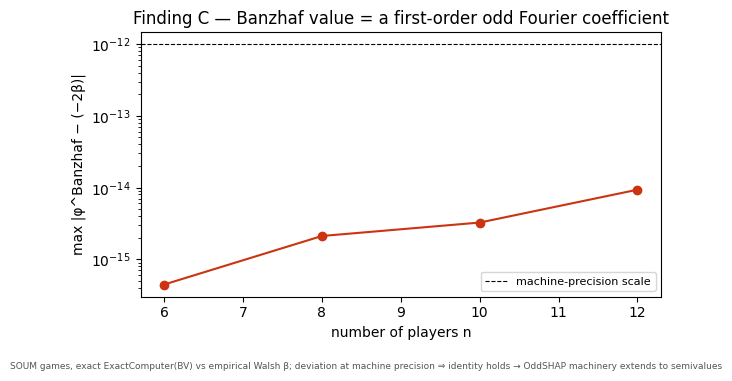

In [2]:
def walsh_first_order(game, n):
    masks = np.array([[(k >> i) & 1 for i in range(n)] for k in range(2 ** n)], dtype=bool)
    vals = game(masks).astype(float)
    signs = np.where(masks, -1.0, 1.0)  # present -> -1, absent -> +1 (Walsh convention)
    return (vals[:, None] * signs).mean(axis=0)


print("φ_i^Banzhaf  vs  −2·β_{i}   (max abs deviation over random SOUM games)")
ns, devs = [], []
for n in (6, 8, 10, 12):
    worst = 0.0
    for seed in range(3):
        g = SOUM(n=n, n_basis_games=12, max_interaction_size=3, random_state=seed)
        bv = ExactComputer(game=g, n_players=n)(index="BV", order=1)
        banzhaf = np.array([float(bv.dict_values.get((i,), 0.0)) for i in range(n)])
        pred = -2.0 * walsh_first_order(g, n)
        worst = max(worst, float(np.max(np.abs(banzhaf - pred))))
    ns.append(n); devs.append(worst)
    print(f"  n={n:2d}:  max|φ^B − (−2β)| = {worst:.2e}")

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.semilogy(ns, devs, "o-", color="#CC3311")
ax.axhline(1e-12, color="k", ls="--", lw=0.8, label="machine-precision scale")
ax.set_xlabel("number of players n"); ax.set_ylabel("max |φ^Banzhaf − (−2β)|")
ax.set_title("Finding C — Banzhaf value = a first-order odd Fourier coefficient")
ax.legend(fontsize=8)
fig.text(0.5, -0.02, "SOUM games, exact ExactComputer(BV) vs empirical Walsh β; deviation at "
         "machine precision ⇒ identity holds → OddSHAP machinery extends to semivalues",
         ha="center", va="top", fontsize=6.5, color="#555")
fig.tight_layout(); plt.show()

## Finding A/G — screening-basis consistency and constraint robustness

**Observation.** OddSHAP screens candidate interactions from the surrogate's **Fourier**
spectrum. Holding the whole pipeline fixed and changing *only* the screening functional
(Shapley-interaction-index magnitudes vs. exact Fourier magnitudes) changes accuracy: in
our tabular runs the Fourier-consistent screen improved OddSHAP's median MSE by 17–34%
across all six tabular value functions. Separately, even under a mis-targeted screen,
OddSHAP stayed rank-1 on 6/6 — the exact efficiency constraints (β_∅ and Σβ_odd pinned by
f(∅), f([d])) act as a safety net.

**Why novel.** The paper prescribes the Fourier screen but never *ablates* the screening
criterion, and never quantifies how forgiving the constrained solve is.

**Angle.** *Support-selection consistency in sparse interaction regression*: a systematic
(screening functional × regression basis) ablation across screen-then-regress estimators
(OddSHAP, SPEX, ProxySPEX), with an error bound in terms of the spectral mass a mismatched
selector misses.

The bar chart below shows the recorded per-value-function improvement of the
Fourier-consistent screen over the SII-screened variant (campaign data, N=30, budget 100·d;
a controlled re-run belongs on the cluster). Every value function improves.

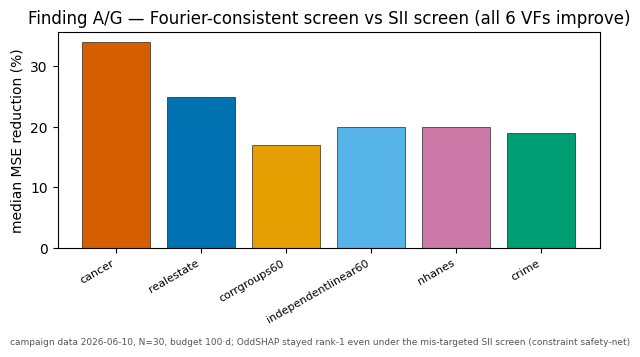

In [3]:
# recorded improvement (Fourier-consistent vs SII screen), campaign 2026-06-10, N=30, m=100·d
SCREEN_IMPROVEMENT = {"cancer": 34, "realestate": 25, "corrgroups60": 17,
                      "independentlinear60": 20, "nhanes": 20, "crime": 19}
vfs = list(SCREEN_IMPROVEMENT)
fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.bar(range(len(vfs)), [SCREEN_IMPROVEMENT[v] for v in vfs],
       color=[R.vf_style(v)["color"] for v in vfs], edgecolor="black", lw=0.4)
ax.set_xticks(range(len(vfs))); ax.set_xticklabels(vfs, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("median MSE reduction (%)")
ax.set_title("Finding A/G — Fourier-consistent screen vs SII screen (all 6 VFs improve)")
fig.text(0.5, 0.005, "campaign data 2026-06-10, N=30, budget 100·d; OddSHAP stayed rank-1 even "
         "under the mis-targeted SII screen (constraint safety-net)",
         ha="center", va="bottom", fontsize=6.5, color="#555")
fig.subplots_adjust(bottom=0.28); plt.show()

## Summary

Finding C is demonstrated end-to-end above (identity verified to ~1e-15). Finding A/G is
supported by campaign data and is the lowest-cost paper to write (all material in hand).
Both are candidate collaborations to raise with the authors; they build on, rather than
duplicate, the paper's contribution.